In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from jinja2 import Template 
import plotly.express as px

In [2]:
colors = sns.set_palette("pastel")

In [3]:
data = pd.read_csv(r'C:\Users\User\Desktop\Project\uk_train_transaction_cleaned.csv')

In [4]:
data.head()

,Transaction_ID,Date_of_Purchase,Time_of_Purchase,Purchase_Type,Payment_Method,Price,Departure_Station,Arrival_Destination,Date_of_Journey,Departure_Time,Arrival_Time,Actual_Arrival_Time,Journey_Status,Reason_for_Delay,Refund_Request,ticket_class,ticket_type,railcard
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,No Delay,No,Standard,Advance,Adult
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No,Standard,Advance,Adult
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,No Delay,No,Standard,Advance,No info
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,No Delay,No,Standard,Advance,No info
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,No Delay,No,Standard,Advance,No info


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Transaction_ID       31653 non-null  str  
 1   Date_of_Purchase     31653 non-null  str  
 2   Time_of_Purchase     31653 non-null  str  
 3   Purchase_Type        31653 non-null  str  
 4   Payment_Method       31653 non-null  str  
 5   Price                31653 non-null  int64
 6   Departure_Station    31653 non-null  str  
 7   Arrival_Destination  31653 non-null  str  
 8   Date_of_Journey      31653 non-null  str  
 9   Departure_Time       31653 non-null  str  
 10  Arrival_Time         31653 non-null  str  
 11  Actual_Arrival_Time  29773 non-null  str  
 12  Journey_Status       31653 non-null  str  
 13  Reason_for_Delay     31653 non-null  str  
 14  Refund_Request       31653 non-null  str  
 15  ticket_class         31653 non-null  str  
 16  ticket_type          31653 non-nu

In [6]:
check_unique = ('Purchase_Type', 'Payment_Method', 'Journey_Status', 'Reason_For_Delay', 'Refund_Request', 'ticket_class', 'ticket_type', 'ticket_destination', 'ticket_origin')
for cols in data.columns:
    if cols in check_unique:
        print(cols, ':', data[cols].unique())

Purchase_Type : <StringArray>
['Online', 'Station']
Length: 2, dtype: str
Payment_Method : <StringArray>
['Contactless', 'Credit Card', 'Debit Card']
Length: 3, dtype: str
Journey_Status : <StringArray>
['On Time', 'Delayed', 'Cancelled']
Length: 3, dtype: str
Refund_Request : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
ticket_class : <StringArray>
['Standard', 'First Class']
Length: 2, dtype: str
ticket_type : <StringArray>
['Advance', 'Off-Peak', 'Anytime']
Length: 3, dtype: str


In [7]:
date_cols = ['Date_of_Purchase', 'Date_of_Journey']
time_cols = ['Arrival_Time', 'Actual_Arrival_Time', 'Time_of_Purchase', 'Departure_Time']

for cols in data.columns:
    if cols in date_cols:
        data[cols] = data[cols].apply(pd.to_datetime, errors='coerce')

    elif cols in time_cols:
        data[cols] = data[cols].apply(lambda col: pd.to_datetime(col, format='%H:%M:%S', errors='coerce').time() if pd.notna(col) else None)

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction_ID       31653 non-null  str           
 1   Date_of_Purchase     31653 non-null  datetime64[us]
 2   Time_of_Purchase     31653 non-null  object        
 3   Purchase_Type        31653 non-null  str           
 4   Payment_Method       31653 non-null  str           
 5   Price                31653 non-null  int64         
 6   Departure_Station    31653 non-null  str           
 7   Arrival_Destination  31653 non-null  str           
 8   Date_of_Journey      31653 non-null  datetime64[us]
 9   Departure_Time       31653 non-null  object        
 10  Arrival_Time         31653 non-null  object        
 11  Actual_Arrival_Time  29773 non-null  object        
 12  Journey_Status       31653 non-null  str           
 13  Reason_for_Delay     31653 non-null  str  

# Minimizing the affect of Unsuccesful trip

Khoảng thời gian trong bộ dữ liệu bắt đầu từ tháng 12-2023 và kết thúc vào tháng 4-2024

## Unsuccessful trip Overview

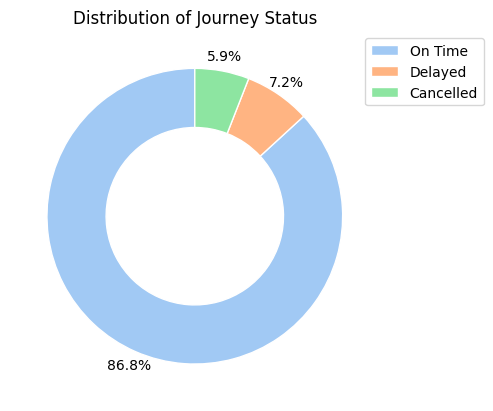

In [9]:
sizes = data['Journey_Status'].value_counts()
labels = sizes.index
fig, ax = plt.subplots()

wedges = ax.pie(sizes, labels=None, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'width': 0.4, 'edgecolor': 'white'}, pctdistance=1.1)
ax.set_title('Distribution of Journey Status')
ax.legend(wedges[0], labels, loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()



In [10]:
detail_journey_status = data[data['Journey_Status'].isin(['Delayed', 'Cancelled'])]
detail_journey_status['month_journey'] = pd.to_datetime(detail_journey_status['Date_of_Journey']).dt.month

table_count = pd.crosstab(
    index = detail_journey_status['Journey_Status'],
    columns = detail_journey_status['month_journey'],
    margins = True,
    margins_name = 'Total'
)

print(table_count)

month_journey      1    2     3     4  Total
Journey_Status                              
Cancelled        475  432   495   478   1880
Delayed          559  561   642   530   2292
Total           1034  993  1137  1008   4172


In [11]:
table_pct = pd.crosstab(
    index = detail_journey_status['Journey_Status'],
    columns = detail_journey_status['month_journey'],
    normalize = 'columns',
    margins = True,
    margins_name = 'Total'
)
table_pct = table_pct.round(2)*100

print(table_pct)

month_journey      1     2     3     4  Total
Journey_Status                               
Cancelled       46.0  44.0  44.0  47.0   45.0
Delayed         54.0  56.0  56.0  53.0   55.0


### **Insights**
1. Trong số các chuyến tàu được chạy, số chuyến tàu đúng giờ chiếm 86.7% tổng số chuyến và có 13.1 các chuyến gặp vấn đề (Delayed, Cancelled)
2. Trong số các chuyến tàu không thành công, số lượng các chuyến tàu gặp vấn đề Delayed luôn nhiều hơn Cancelled và số lượng các các chuyến tàu gặp lỗi vận hành không chênh lệch quá nhiều giữa các tháng.
3. Nhưng có thể thấy rằng, vào tháng 1 và 3 là 2 tháng có chuyến tàu không thành công nhiều hơn các tháng còn lại

## Delay reasons analysis

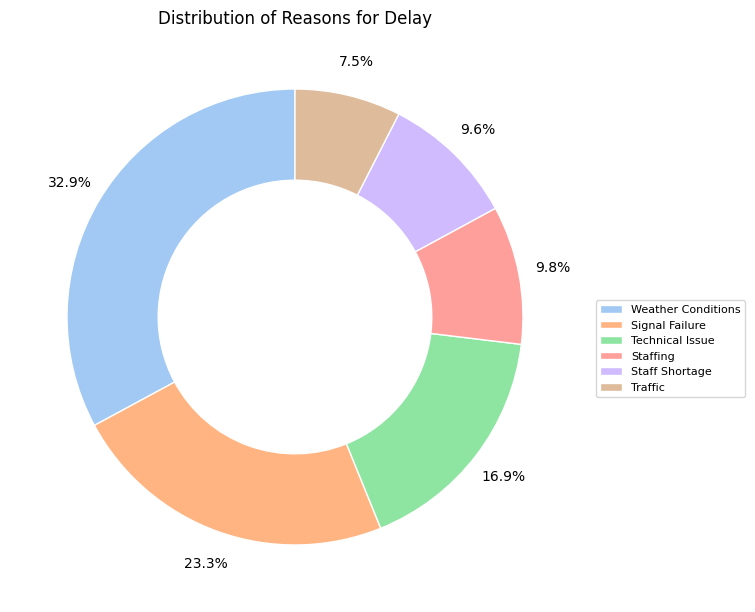

In [12]:
reason_delay = detail_journey_status.loc[
    detail_journey_status['Reason_for_Delay'] != 'No Delay',
    'Reason_for_Delay'
].value_counts()

index_reason = reason_delay.index

fig, ax = plt.subplots(figsize=(8, 6))

wedges = ax.pie(
    reason_delay,
    labels = None,
    autopct = '%1.1f%%',
    startangle = 90,
    colors=colors,
    wedgeprops={'width':0.4, 'edgecolor':'white'},
    pctdistance=1.15
)
plt.tight_layout()
ax.set_title('Distribution of Reasons for Delay')
ax.legend(wedges[0], index_reason, loc='lower right', bbox_to_anchor=(1.3, 0.35), fontsize=8, labelspacing=0.5)

In [13]:
delay_time = data.dropna(subset=['Actual_Arrival_Time', 'Arrival_Time']).copy()
delay_time = delay_time.loc[delay_time['Reason_for_Delay'] != 'No Delay', :]

actual_td = pd.to_timedelta(delay_time['Actual_Arrival_Time'].astype(str))
arrival_td = pd.to_timedelta(delay_time['Arrival_Time'].astype(str))

delay_time['Delay_Time'] = (actual_td - arrival_td).dt.total_seconds() / 60
delay_time.loc[delay_time['Delay_Time'] < -720, 'Delay_Time'] += 1440

In [14]:
table_delay = delay_time.groupby('Reason_for_Delay')['Delay_Time'].mean().round(2).sort_values(ascending=False)
table_delay

Reason_for_Delay
Staff Shortage        74.93
Signal Failure        51.81
Weather Conditions    43.84
Traffic               32.34
Staffing              25.91
Technical Issue       24.92
Name: Delay_Time, dtype: float64

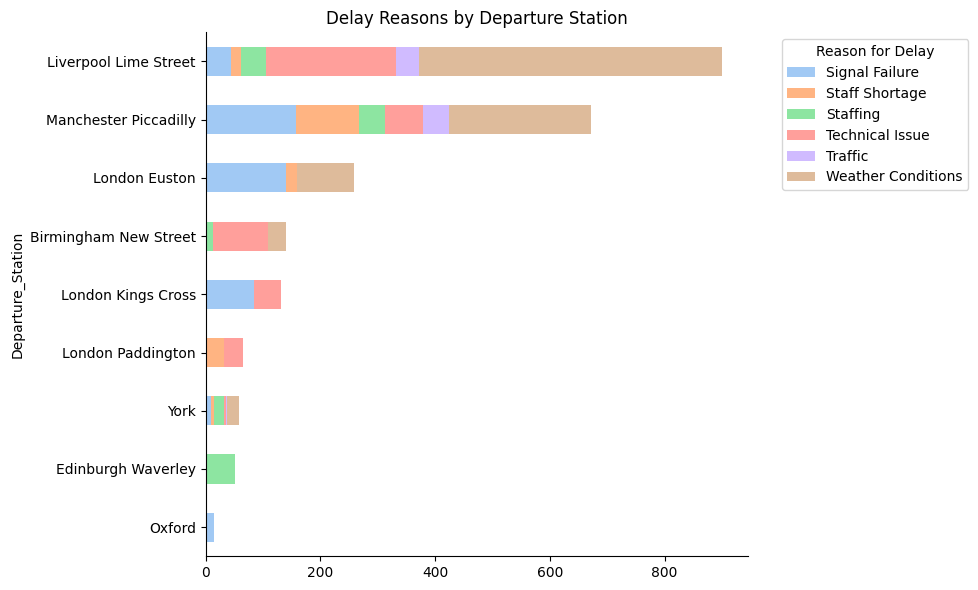

In [15]:
df_percent_delay = pd.crosstab(
    index=delay_time['Departure_Station'],
    columns=delay_time.loc[delay_time['Reason_for_Delay'] != 'No Delay', 'Reason_for_Delay'],
)

df_percent_delay['Total'] = df_percent_delay.sum(axis=1)
df_percent_delay = df_percent_delay.sort_values(by='Total'  , ascending=True)
df_percent_delay = df_percent_delay.drop(columns='Total')

ax = df_percent_delay.plot(kind='barh', stacked=True, figsize=(10, 6), color=colors)
ax.set_title('Delay Reasons by Departure Station')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='Reason for Delay', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


### **Insights**
1. Trong các yếu tố gây trễ, yếu tố thời tiết là yếu tố bên ngoài chính ảnh hưởng đến chất lượng chuyến tàu. Trong khi đó các vấn đề về Signal failure, Staff, Technical Issue là nhưng nhân tố chính về vận hành ảnh hưởng đến thời gian chạy.
2. Trung bình thời gian delay các chuyến tàu khoảng 42 phút. Vấn đề về Thiếu hụt nhân lực và Tín hiệu tốn nhiều thời gian để khắc phục (>42).
3. Các điểm xuất phát thường xảy ra hiện tượng delay bao gồm: Liverpool Lime Street, Manchester Piccadilly, London Eustion. (Bỏ qua yếu tố thời tiết). Signal Failure thường xảy ra ở Manchester và London Euston, Technical Issue thường gặp ở Liverpool Lime Street và Staff-related Issue thường thấy ở London và Manchester

## Journey Issue Overtime

In [16]:
from pandas.api.types import CategoricalDtype

part_of_day = {
    'Morning' : (pd.to_timedelta('05:00:00'), pd.to_timedelta('11:59:59')),
    'Afternoon' : (pd.to_timedelta('12:00:00'), pd.to_timedelta('16:59:59')),
    'Evening' : (pd.to_timedelta('17:00:00'), pd.to_timedelta('21:59:59')),
    'Night' : (pd.to_timedelta('22:00:00'), pd.to_timedelta('04:59:59'))
}

'''
part_of_day.keys() Python sẽ trả về một tập hợp chứa các key của từ điển (dictionary) như thế này:
dict_keys(['Morning', 'Afternoon', 'Evening', 'Night'])

*part_of_day.keys() sẽ giải nén (unpack) các key của từ điển thành một danh sách. Kết quả sẽ là:
['Morning', 'Afternoon', 'Evening', 'Night']

'''
part_of_day_dtype = CategoricalDtype(categories=[*part_of_day.keys(), 'Unknown'], ordered=True)

def assign_part_of_day(time):
    if pd.isna(time):
        return 'Unknown'
    time_td = pd.to_timedelta(time.strftime('%H:%M:%S'))
    for part, (start, end) in part_of_day.items():
        if start <= end:
            if start <= time_td <= end:
                return part
        else:
            if time_td >= start or time_td <= end:
                return part
    return 'Unknown'

journey_time = data.copy()
journey_time['Part_of_Day'] = journey_time['Departure_Time'].apply(assign_part_of_day).astype(part_of_day_dtype) #để áp thứ tự được định trước thì dùng astype để chuyển đổi sang kiểu dữ liệu đã định nghĩa
journey_time

,Transaction_ID,Date_of_Purchase,Time_of_Purchase,Purchase_Type,Payment_Method,Price,Departure_Station,Arrival_Destination,Date_of_Journey,Departure_Time,Arrival_Time,Actual_Arrival_Time,Journey_Status,Reason_for_Delay,Refund_Request,ticket_class,ticket_type,railcard,Part_of_Day
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,No Delay,No,Standard,Advance,Adult,Morning
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No,Standard,Advance,Adult,Morning
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,No Delay,No,Standard,Advance,No info,Evening
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,No Delay,No,Standard,Advance,No info,Evening
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,No Delay,No,Standard,Advance,No info,Afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31648,1304623d-b8b7-4999-8e9c,2024-04-30,18:42:58,Online,Credit Card,4,Manchester Piccadilly,Liverpool Lime Street,2024-04-30,20:00:00,20:30:00,20:30:00,On Time,No Delay,No,Standard,Off-Peak,No info,Evening
31649,7da22246-f480-417c-bc2f,2024-04-30,18:46:10,Online,Contactless,10,London Euston,Birmingham New Street,2024-04-30,20:15:00,21:35:00,21:35:00,On Time,No Delay,No,Standard,Off-Peak,No info,Evening
31650,add9debf-46c1-4c75-b52d,2024-04-30,18:56:41,Station,Credit Card,4,Manchester Piccadilly,Liverpool Lime Street,2024-04-30,20:15:00,20:45:00,20:45:00,On Time,No Delay,No,Standard,Off-Peak,No info,Evening
31651,b92b047c-21fd-4859-966a,2024-04-30,19:51:47,Station,Credit Card,10,London Euston,Birmingham New Street,2024-04-30,21:15:00,22:35:00,22:35:00,On Time,No Delay,No,Standard,Off-Peak,No info,Evening


In [17]:
count_journey =journey_time['Part_of_Day'].value_counts().reindex(part_of_day.keys())
count_journey

Part_of_Day
Morning      11709
Afternoon     6425
Evening       8067
Night         5452
Name: count, dtype: int64

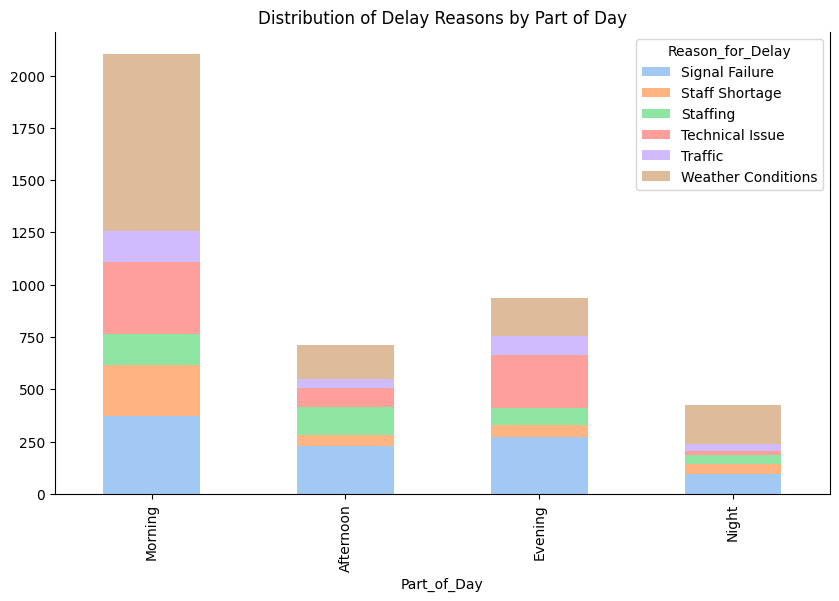

In [18]:
table_journey = pd.crosstab(
    index=journey_time['Part_of_Day'],
    columns=journey_time.loc[journey_time['Reason_for_Delay']!= 'No Delay', 'Reason_for_Delay'],
)
ax = table_journey.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
ax.set_title('Distribution of Delay Reasons by Part of Day')
ax.spines['top'].set_visible(False)


In [19]:
table_journey = pd.crosstab(
    index=journey_time.loc[journey_time['Reason_for_Delay']!= 'No Delay', 'Reason_for_Delay'],
    columns=journey_time['Part_of_Day'],
    normalize='columns'
).round(2)*100
table_journey

Part_of_Day,Morning,Afternoon,Evening,Night
Reason_for_Delay,,,,
Signal Failure,18.0,32.0,29.0,22.0
Staff Shortage,11.0,7.0,6.0,12.0
Staffing,7.0,19.0,9.0,10.0
Technical Issue,16.0,13.0,27.0,5.0
Traffic,7.0,6.0,10.0,8.0
Weather Conditions,40.0,23.0,19.0,43.0


### **Insights**
1. Buổi sáng (5am-9am) là thời điểm thường xuyên xảy ra tình trạng trễ tàu, chịu ảnh hưởng chính bởi yếu tố thời tiết và lỗi kĩ thuật.
2. Theo sau đó là buổi tối (5pm-10pm) và buổi trưa chiều (12am-5pm) cùng chịu ảnh hưởng chính của Signal failure và Technical Issue. Ngoài ra vào buổi trưa chiều còn gặp phải vấn đề về Staffing.
3. Vào buổi khuya (Night) chịu ảnh hưởng nhiều nhất của vấn đề thời tiết, Signal Failure cũng là yếu tố gây ảnh hưởng chính đến thời gian chạy của tàu trong thời điểm này

## Refund Overview

In [20]:
df_refund = data.copy()

In [21]:
refund_request = df_refund.loc[df_refund['Reason_for_Delay'] != 'No Delay', 'Refund_Request']

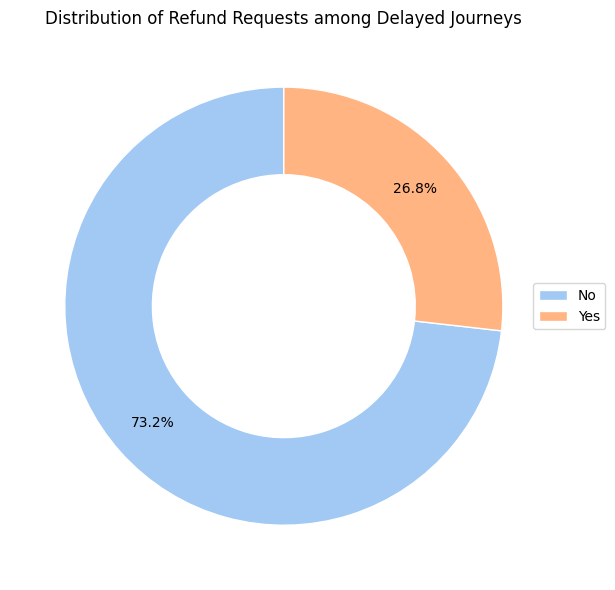

In [22]:
sizes_refund = refund_request.value_counts()
index_refund = sizes_refund.index

fig, ax = plt.subplots(figsize=(10, 6))

wedges = ax.pie(
    sizes_refund,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'width':0.4, 'edgecolor':'white'},
    pctdistance=0.8
)
ax.legend(wedges[0], index_refund, loc='center right', bbox_to_anchor=(1.1, 0.5), fontsize=10, labelspacing=0.5)
ax.set_title('Distribution of Refund Requests among Delayed Journeys')
plt.tight_layout()

In [23]:
refund_request = df_refund.loc[(df_refund['Journey_Status'] != 'On Time') & (df_refund['Refund_Request'] == 'Yes'), :].copy()
refund_request['month_journey'] = pd.to_datetime(refund_request['Date_of_Journey']).dt.month

result_refund = pd.pivot_table(
    data=refund_request,
    index='month_journey',
    columns='Journey_Status',
    values=['Transaction_ID', 'Price'],
    aggfunc={'Transaction_ID': 'count', 'Price': 'sum'},
    margins=True,
    margins_name='Total'
)
result_refund = result_refund.drop(columns='Total', level=1, errors='ignore')
# result_refund = result_refund.swaplevel(0,1,axis=1).sort_index(axis=1)
result_refund

Price         Transaction_ID        
Journey_Status Cancelled Delayed      Cancelled Delayed
month_journey                                          
1                   3784    7222            155     134
2                   2537    5308            130     123
3                   3467    7087            158     148
4                   2749    6548            129     141
Total              12537   26165            572     546

### **Insights**
1. Trong số các khách hàng đi phải tàu gặp lỗi, có 26.8% lượt yêu cầu hoàn tiền. Tổng chi phí cho các đợt hoàn tiền này là 38702 euro.
2. Các lượt đi gặp lỗi và tháng 1 và tháng 3 thường sẽ yêu cầu hoàn tiền hơn với (313/595 trường hợp trong 2 tháng này).
3. Mặc dù trường hợp Cancelled có số lượng yêu cầu hoàn tiền nhiều hơn nhưng chi phí lại tốn ít hơn khi so với Delayed.

## Refund Reason Analysis

Text(0.5, 1.0, 'Distribution of Total Refund Cost by Reason for Delay')

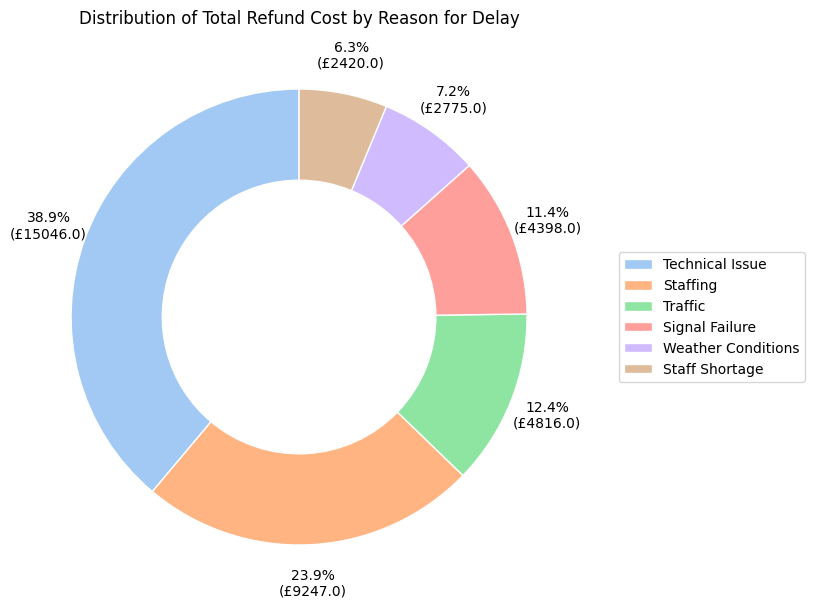

In [24]:
cost_reason_refund = refund_request.groupby('Reason_for_Delay')['Price'].sum().round(2).sort_values(ascending=False)
cost_index = cost_reason_refund.index

fig, ax = plt.subplots(figsize=(10,6))

my_autopct = lambda p: f'{p:.1f}%\n(£{p * cost_reason_refund.sum() / 100:.1f})'

wedges = ax.pie(
    cost_reason_refund,
    labels=None,
    autopct=my_autopct,
    startangle=90,
    colors=colors,
    wedgeprops={'width':0.4, 'edgecolor':'white'},
    pctdistance=1.17
)

ax.legend(wedges[0], cost_index, loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize=10, labelspacing=0.5)
plt.tight_layout()
ax.set_title('Distribution of Total Refund Cost by Reason for Delay')

In [25]:
# Pivot với số thô
pct_refund_table = pd.pivot_table(
    data=refund_request,
    index='Reason_for_Delay',
    columns='Journey_Status',
    values=['Transaction_ID', 'Price'],
    aggfunc={'Transaction_ID':'count', 'Price' : 'sum'},
    margins=True,
    margins_name='Total',
    fill_value=0
)

#xóa cột Total, đảo header và sắp xếp chữ cái
pct_refund_table = pct_refund_table.drop(columns='Total',level=1, errors='ignore')
pct_refund_table = pct_refund_table.swaplevel(0,1,axis=1).sort_index(axis=1)

# Tính tổng số lượng refund request
grandtotal = pct_refund_table.loc['Total', ('Delayed', 'Transaction_ID')] + \
             pct_refund_table.loc['Total', ('Cancelled', 'Transaction_ID')]

# Tạo cột % mới cho Cancelled và Delayed
pct_refund_table[('Cancelled', '% of Refund Request')] = (pct_refund_table[('Cancelled', 'Transaction_ID')]/ grandtotal).round(3)*100
pct_refund_table[('Delayed', '% of Refund Request')] = (pct_refund_table[('Delayed', 'Transaction_ID')]/ grandtotal).round(3)*100

pct_refund_table = pct_refund_table.rename(columns={'Price': 'Total Cost'})
pct_refund_table = pct_refund_table.drop(columns=[('Cancelled', 'Transaction_ID'), ('Delayed', 'Transaction_ID')], errors='ignore')

pct_refund_table = pct_refund_table[[
    ('Cancelled', '% of Refund Request'), ('Cancelled', 'Total Cost'),
    ('Delayed', '% of Refund Request'), ('Delayed', 'Total Cost')
]]

In [26]:
pct_refund_table

Journey_Status               Cancelled                        Delayed  \
                   % of Refund Request Total Cost % of Refund Request   
Reason_for_Delay                                                        
Signal Failure                    13.9       3081                 5.4   
Staff Shortage                     5.9       1549                 1.2   
Staffing                           6.4       1637                 9.8   
Technical Issue                    6.4       1819                28.3   
Traffic                            6.6       1676                 4.2   
Weather Conditions                11.9       2775                 0.0   
Total                             51.2      12537                48.8   

Journey_Status                 
                   Total Cost  
Reason_for_Delay               
Signal Failure           1317  
Staff Shortage            871  
Staffing                 7610  
Technical Issue         13227  
Traffic                  3140  
Weather Conditions          0  
Total                   26165

### **Insights**
1. Technical Issue dẫn đầu lý do yêu cầu hoàn tiền, theo sau đó là Staffing và Traffic --> Đây là các yếu tố chính (87%) lý do khách hành yêu cầu hoàn trả tiền chuyến đi.
2. Với Delayed trips: Technical Issue và Staffing là những lỗi khiến khách hàng muốn hoàn tiền nhất.
3. Với Cancelled trips: Chủ yếu đến từ Signal Failure.

# Enhancing Customer satisfaction

## Purchase Behavior

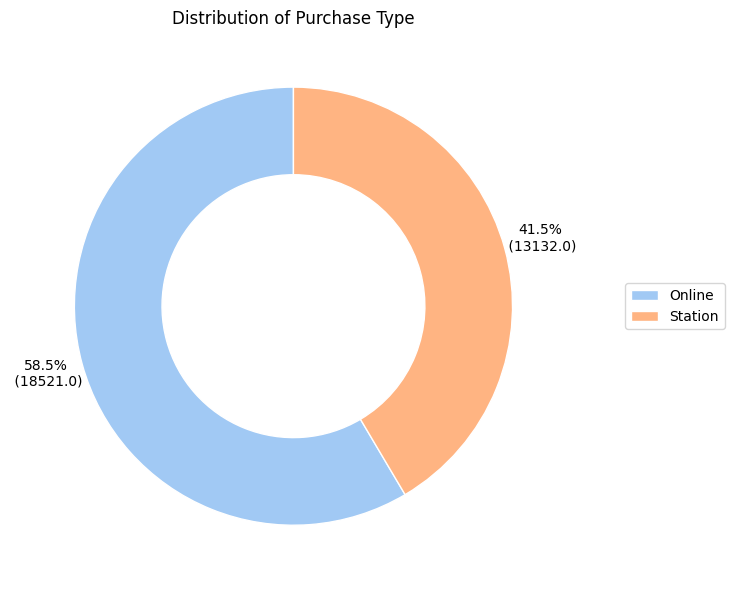

In [27]:
purchase_type = data['Purchase_Type'].value_counts()
purchase_type_indx = purchase_type.index 

fig, ax = plt.subplots(figsize=(10, 6))

my_atuopct = lambda p: f'{p:.1f}%\n ({purchase_type.sum() * p/100:.1f})'
wedges = ax.pie(
    purchase_type,
    labels=None,
    autopct = my_atuopct,
    startangle=90,
    wedgeprops={'width':0.4, 'edgecolor':'white'},
    pctdistance=1.17,
    colors=colors
)

ax.legend(wedges[0], purchase_type_indx, loc='center right', bbox_to_anchor=(1.3, 0.5), fontsize=10, labelspacing=0.5)
ax.set_title('Distribution of Purchase Type')
plt.tight_layout()


In [28]:
purchase_type_by_time = data.copy()
purchase_type_by_time['month_year'] = pd.to_datetime(purchase_type_by_time['Date_of_Purchase']).dt.to_period('M')

table_purchase_time = pd.crosstab(
    index = purchase_type_by_time['Purchase_Type'],
    columns= purchase_type_by_time['month_year'],
    margins=True,
    margins_name='Total'
)
print(table_purchase_time)

month_year     2023-12  2024-01  2024-02  2024-03  2024-04  Total
Purchase_Type                                                    
Online              23     4914     4375     4702     4507  18521
Station             11     3520     2962     3398     3241  13132
Total               34     8434     7337     8100     7748  31653


In [29]:
table_purchase_time_pct = pd.crosstab(
    index = purchase_type_by_time['Purchase_Type'],
    columns= purchase_type_by_time['month_year'],
    normalize='columns',
    margins=True,
    margins_name='Total'
)
table_purchase_time_pct = table_purchase_time_pct.round(5)*100
table_purchase_time_pct = table_purchase_time_pct.style.bar(
    color='#FF9966',
    axis=1,
    vmin=0,
    vmax=100
).format(
    "{:.2f}%"               # Ép format: Làm tròn 2 số thập phân và thêm dấu %
).set_properties(
    **{'color': 'white'}    
)
table_purchase_time_pct

month_year,2023-12,2024-01,2024-02,2024-03,2024-04,Total
Purchase_Type,,,,,,
Online,67.65%,58.26%,59.63%,58.05%,58.17%,58.51%
Station,32.35%,41.74%,40.37%,41.95%,41.83%,41.49%


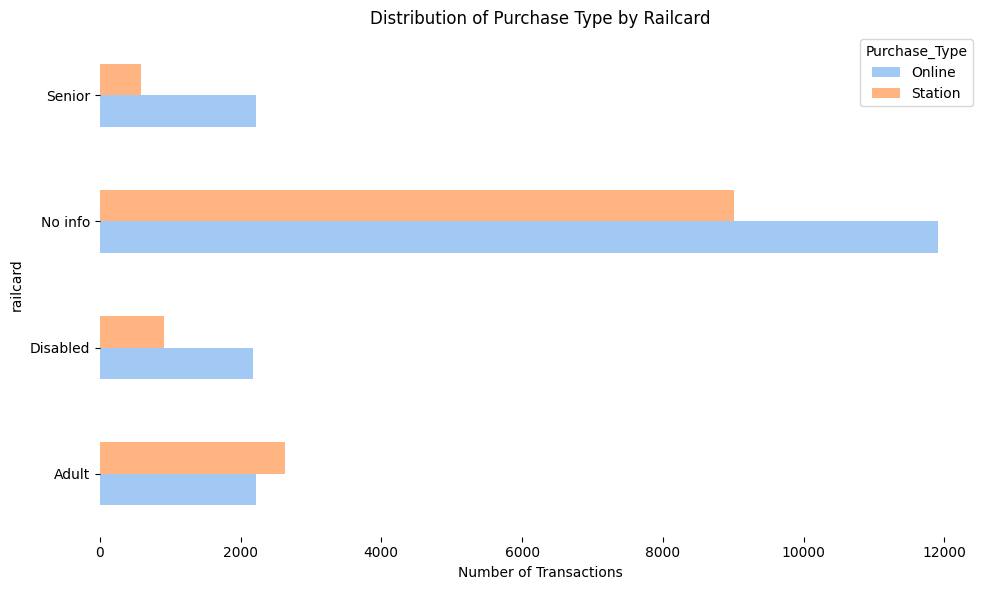

In [30]:
df_ticket = data[['railcard', 'Purchase_Type', 'Transaction_ID']]

table_ticket = pd.crosstab(
    index = df_ticket['railcard'],
    columns = df_ticket['Purchase_Type'],
    values='Transaction_ID',
    aggfunc='count'   
)

ax = table_ticket.plot(
    kind = 'barh',
    stacked=False,
    figsize=(10,6),
    color=colors
)

ax.set_title('Distribution of Purchase Type by Railcard')
ax.set_xlabel('Number of Transactions')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()

In [31]:
pivot_purchase = pd.pivot_table(
    data = purchase_type_by_time,
    index = ['Purchase_Type', 'railcard'],
    columns='month_year',
    values='Transaction_ID',
    aggfunc='count',
    fill_value=0
)
styled_pivot = pivot_purchase.style.background_gradient(
    cmap='Oranges',  # Chọn dải màu Cam (Giống trong báo cáo của bạn)
    axis=None,       # axis=None: So sánh lớn/nhỏ trên TOÀN BỘ bảng. 
                     # (Nếu để axis=0: Chỉ so sánh trong từng cột, axis=1: so sánh trong từng hàng dọc)
    text_color_threshold=0.5 # Ngưỡng để đổi màu chữ, nếu giá trị lớn hơn 0.5 sẽ đổi màu chữ thành trắng, ngược lại sẽ là đen
)
styled_pivot

In [32]:
pivot_purchase_pct = pivot_purchase.div(
    pivot_purchase.sum(axis=0),
    axis=1
).round(4)*100

pivot_purchase_pct = pivot_purchase_pct.style.bar(
    color='#FF9966',
    axis=1,
    vmin=0,
    vmax=100
).format(
    "{:.2f}%"               # Ép format: Làm tròn 2 số thập phân và thêm dấu %
).set_properties(
    **{'color': 'white'}
)

pivot_purchase_pct

* Advanced: Vé đặt trước
* Off-peak: Vé di chuyển ngoài giờ cao điểm
* Anytime: Vé mua cho đi bất kì chuyến đi nào 

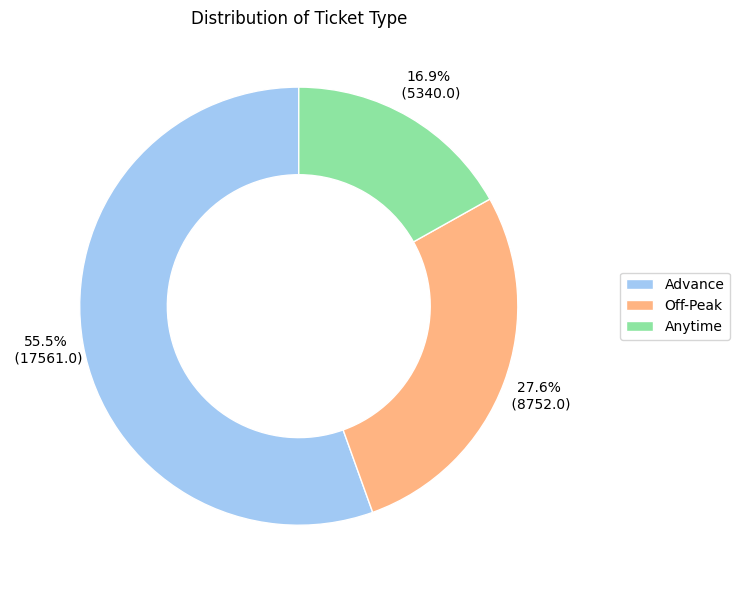

In [33]:
size_ticket_type = data['ticket_type'].value_counts()
ticket_idx = size_ticket_type.index

fig, ax = plt.subplots(figsize=(10, 6))

my_atuopct = lambda p: f'{p:.1f}%\n ({size_ticket_type.sum()*p/100:.1f})'

wedeges = ax.pie(
    size_ticket_type,
    labels=None,
    autopct=my_atuopct,
    startangle=90,
    wedgeprops={'width':0.4, 'edgecolor':'white'},
    colors=colors,
    pctdistance=1.17
)

ax.legend(wedeges[0], ticket_idx, loc='center right', bbox_to_anchor=(1.3, 0.5), fontsize=10, labelspacing=0.5)
ax.set_title('Distribution of Ticket Type')
plt.tight_layout()


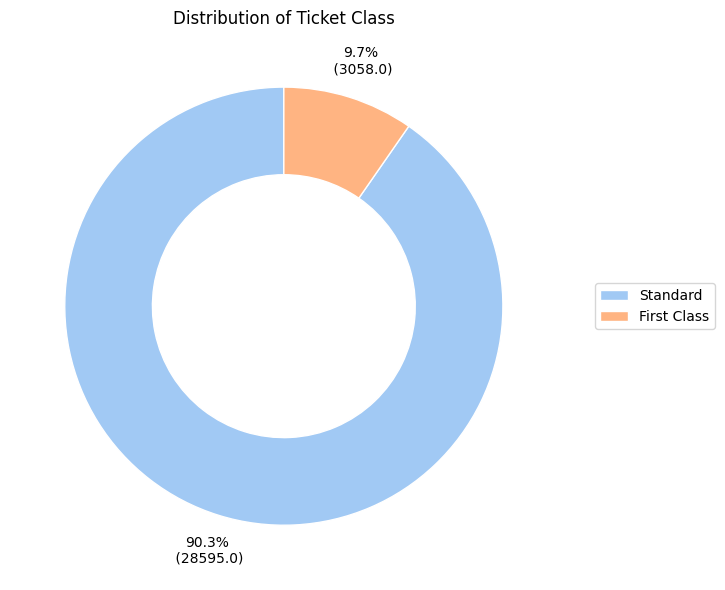

In [34]:
size_ticket_class = data['ticket_class'].value_counts()
ticket_class_idx = size_ticket_class.index

fig, ax = plt.subplots(figsize=(10, 6))

my_autopct = lambda p: f'{p:.1f}%\n ({size_ticket_class.sum()*p/100:.1f})'

wedges = ax.pie(
    size_ticket_class,
    labels=None,
    autopct=my_autopct,
    startangle=90,
    colors=colors,
    wedgeprops={'width':0.4, 'edgecolor':'white'},
    pctdistance=1.17
)
ax.legend(wedges[0], ticket_class_idx, loc='center right', bbox_to_anchor=(1.3, 0.5), fontsize=10, labelspacing=0.5)
ax.set_title('Distribution of Ticket Class')
plt.tight_layout()

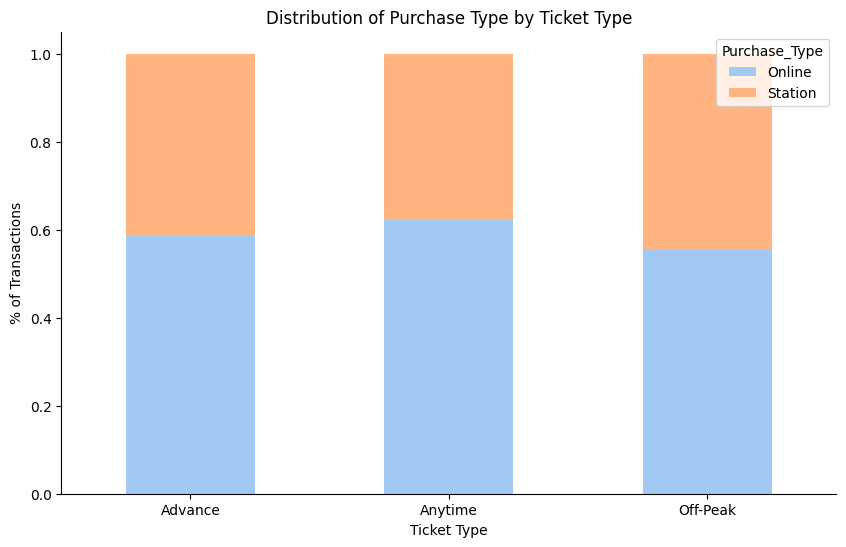

In [35]:
table_ticket_class = pd.crosstab(
    index = data['ticket_type'],
    columns=data['Purchase_Type'],
    values='Transaction_ID',
    aggfunc='count',
    normalize='index'
)

ax = table_ticket_class.plot(
    kind='bar',
    stacked='True',
    figsize=(10, 6),
    color=colors,
    rot=0
)
ax.set_title('Distribution of Purchase Type by Ticket Type')
ax.set_xlabel('Ticket Type')
ax.set_ylabel('% of Transactions')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

## In-depth Price Analysis

In [36]:
data['Price'].describe()

count    31653.000000
mean        23.439200
std         29.997628
min          1.000000
25%          5.000000
50%         11.000000
75%         35.000000
max        267.000000
Name: Price, dtype: float64

<Axes: ylabel='Frequency'>

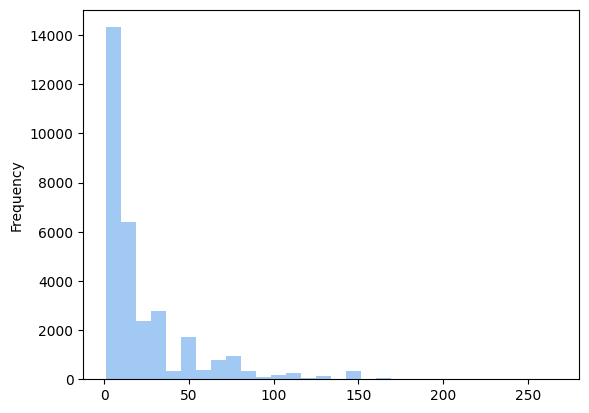

In [37]:
data['Price'].plot(
    kind='hist',
    bins=30,
    color=colors
)

In [38]:
# labels = ['Low', 'Medium', 'Medium High', 'High']

# data['Price_category'] = data.groupby('ticket_class')['Price'].transform(\
#     lambda x: pd.qcut(x, q=4, labels=labels, duplicates='drop'))

# # data['Price_category'] = pd.qcut(data['Price'], q=4, labels=labels, duplicates='drop')

# print(data['Price_category'].value_counts())

bins = [0, 15, 40, 90, np.inf]
labels = ['Low', 'Medium', 'Medium High', 'High']

data['Price_category'] = pd.cut(data['Price'], bins=bins, labels=labels, include_lowest=True)

print(data['Price_category'].value_counts())

Price_category
Low            19450
Medium          6551
Medium High     4424
High            1228
Name: count, dtype: int64


In [39]:
data['ticket_price_class'] = data['ticket_class'].astype(str)+'-'+data['Price_category'].astype(str)
data['ticket_price_class'].unique()

<StringArray>
[   'Standard-Medium High',         'Standard-Medium',
            'Standard-Low',      'First Class-Medium',
 'First Class-Medium High',        'First Class-High',
           'Standard-High',         'First Class-Low']
Length: 8, dtype: str

In [40]:
pivot_ticket_class = pd.pivot_table(
    data=data,
    index='ticket_class',
    columns='Purchase_Type',
    values='Price',
    aggfunc='mean'
).round(2)

pivot_ticket_type = pd.pivot_table(
    data=data,
    index='ticket_type',
    columns='Purchase_Type',
    values='Price',
    aggfunc='mean'
).round(2)

In [41]:
pivot_ticket_class

Purchase_Type,Online,Station
ticket_class,,
First Class,44.67,54.69
Standard,18.11,24.41


In [42]:
pivot_ticket_type

Purchase_Type,Online,Station
ticket_type,,
Advance,15.54,20.58
Anytime,31.73,51.58
Off-Peak,24.00,27.41


In [43]:
purchase_type_class_price = pd.crosstab(
    index=data['ticket_price_class'],
    columns=data['Purchase_Type'],
    values=data['Transaction_ID'],
    aggfunc='count',
    normalize='index'
).round(4)*100

purchase_type_class_price

Purchase_Type,Online,Station
ticket_price_class,,
First Class-High,44.03,55.97
First Class-Low,61.66,38.34
First Class-Medium,59.02,40.98
First Class-Medium High,59.65,40.35
Standard-High,32.99,67.01
Standard-Low,59.38,40.62
Standard-Medium,65.74,34.26
Standard-Medium High,47.53,52.47


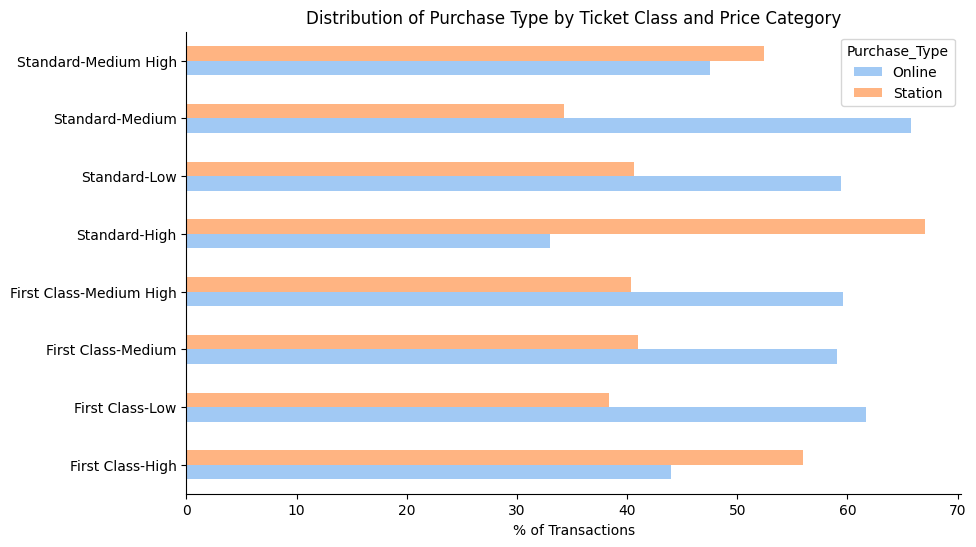

In [44]:
ax = purchase_type_class_price.plot(
    kind='barh',
    stacked=False,
    figsize=(10, 6),
    color=colors,
    rot=0
)
ax.set_title('Distribution of Purchase Type by Ticket Class and Price Category')
ax.set_xlabel('% of Transactions')
ax.set_ylabel('')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [45]:
check_standard = data[data['ticket_class'] == 'Standard']['Price'].describe()
check_first = data[data['ticket_class'] == 'First Class']['Price'].describe()

print(check_standard)
print(check_first)

count    28595.000000
mean        20.721175
std         27.189922
min          1.000000
25%          4.000000
50%         10.000000
75%         24.000000
max        171.000000
Name: Price, dtype: float64
count    3058.000000
mean       48.855134
std        41.069919
min         4.000000
25%        15.000000
50%        41.000000
75%        59.000000
max       267.000000
Name: Price, dtype: float64


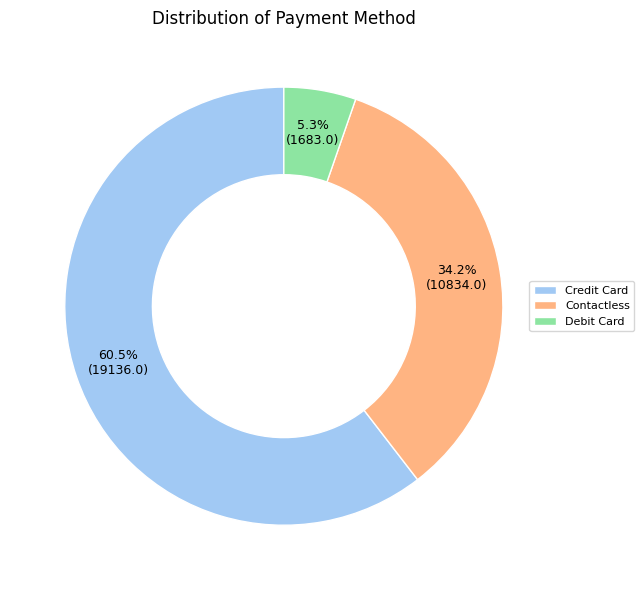

In [46]:
payment_method = data['Payment_Method'].value_counts()
payment_method_idx = payment_method.index

fig,ax =plt.subplots(figsize=(10, 6))

my_autopct = lambda p: f'{p:.1f}%\n({payment_method.sum() * p/100:.1f})'

wedges = ax.pie(
    payment_method,
    labels=None,
    autopct=my_autopct,
    startangle=90,
    colors=colors,
    wedgeprops={'width':0.4, 'edgecolor':'white'},
    pctdistance=0.8,
    textprops={'fontsize':9}
)

ax.legend(wedges[0], payment_method_idx, loc='center right', bbox_to_anchor=(1.15, 0.5), fontsize=8, labelspacing=0.5)
ax.set_title('Distribution of Payment Method')
plt.tight_layout()

In [47]:
pay_method_price = pd.pivot_table(
    data=data,
    index='Payment_Method',
    values='Price',
    aggfunc='mean'
).round(2)
pay_method_price

,Price
Payment_Method,
Contactless,20.26
Credit Card,24.54
Debit Card,31.47


In [48]:
payment_ticket_class = pd.pivot_table(
    data=data,
    index='ticket_class',
    columns='Payment_Method',
    values='Price',
    aggfunc='mean'
).round(2)
payment_ticket_class = payment_ticket_class.rename_axis(index={'ticket_class': 'Ticket Class'}, columns=None)
payment_ticket_class

,Contactless,Credit Card,Debit Card
Ticket Class,,,
First Class,43.83,50.62,59.90
Standard,17.76,21.75,28.13


In [49]:
payment_ticket_type = pd.pivot_table(
    data=data,
    index='ticket_type',
    columns='Payment_Method',
    values='Price',
    aggfunc='mean'
).round(2)

payment_ticket_type = payment_ticket_type.rename_axis(index={'ticket_type':'Ticket Type'}, columns=None)
payment_ticket_type

,Contactless,Credit Card,Debit Card
Ticket Type,,,
Advance,15.70,18.28,22.84
Anytime,33.94,40.39,44.86
Off-Peak,23.28,26.19,37.08


In [50]:
contactless_payment = data.copy()

fig = px.histogram(
    data_frame=contactless_payment,
    x="Price",
    color="ticket_class",               # Tương đương tham số 'hue' trong Seaborn                 # CHÌA KHÓA: Ép 2 nhóm đè lên nhau thay vì xếp chồng lên đỉnh nhau
    opacity=0.6,                        # Độ trong suốt để nhìn xuyên thấu (0 đến 1)
    color_discrete_sequence=['#f5c542', '#d92b2b'], # Mã màu Vàng (Standard) và Đỏ (First Class)
    histnorm="density",                 # Tùy chọn: Chuẩn hóa cột Y thành dạng mật độ phân phối
    barmode="overlay",
    title="Distribution of Ticket Price by Ticket Class",
    facet_row="Payment_Method"
)
# Xóa chữ "Payment_Method=" ở các tiêu đề phụ bên phải
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

# Tinh chỉnh giao diện trắng, viền đen
fig.update_layout(
    plot_bgcolor='white',
    height=800, # Tăng chiều cao biểu đồ lên vì giờ có tới 3 hình xếp chồng
    hovermode='x unified'
)

fig.update_xaxes(showline=True, linewidth=1, linecolor='black', gridcolor=None)
fig.update_yaxes(showline=True, linewidth=1, linecolor='black', gridcolor=None, showticklabels=False) # Ẩn số trục Y cho gọn giống ảnh gốc

fig.update_yaxes(matches=None)
fig.update_yaxes(matches=None, showticklabels=True)

fig.show()

In [51]:
data['lead_time'] = (data['Date_of_Journey'] - data['Date_of_Purchase']).dt.days
data['lead_time'].describe()

count    31653.000000
mean         1.655957
std          3.853255
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max         28.000000
Name: lead_time, dtype: float64

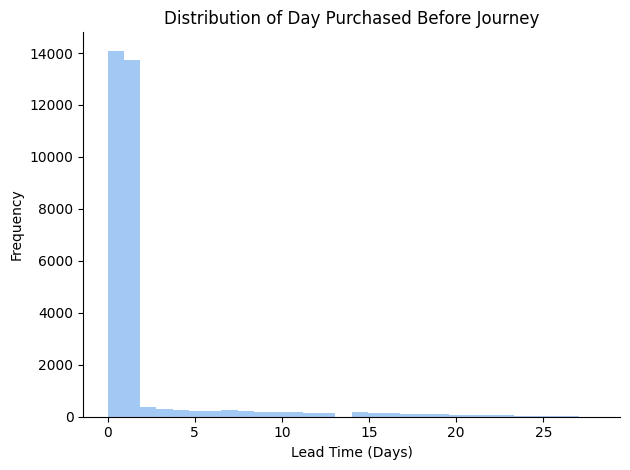

In [52]:
ax = data['lead_time'].plot(
    kind='hist',
    bins=30,
    color=sns.color_palette("pastel")[0]

)
ax.set_title('Distribution of Day Purchased Before Journey')
ax.set_xlabel('Lead Time (Days)')
ax.set_ylabel('Frequency')
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

In [53]:
avg_lead_time_ticket = data.groupby('ticket_price_class')['lead_time'].mean().round(2).sort_values(ascending=True)
avg_lead_time_ticket

ticket_price_class
Standard-High              0.00
First Class-High           0.75
Standard-Medium High       1.16
Standard-Medium            1.55
First Class-Medium High    1.63
First Class-Low            1.76
Standard-Low               1.86
First Class-Medium         1.93
Name: lead_time, dtype: float64

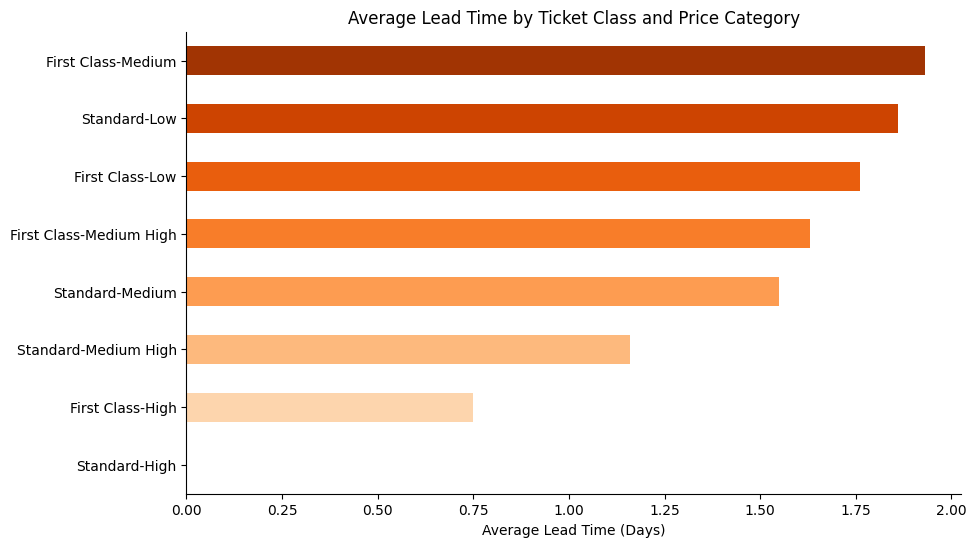

In [54]:
gradient_colors = sns.color_palette("Oranges", n_colors=len(avg_lead_time_ticket))
ax=avg_lead_time_ticket.plot(
    kind='barh',
    color=gradient_colors,
    figsize=(10, 6) 
)
ax.set_title('Average Lead Time by Ticket Class and Price Category')
ax.set_ylabel('')
ax.set_xlabel('Average Lead Time (Days)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

## Travel Behaviour

In [60]:
data['time_journey'] = pd.to_timedelta(data['Arrival_Time'].astype(str)) - pd.to_timedelta(data['Departure_Time'].astype(str))
data['time_journey'] = data['time_journey'].dt.total_seconds() / 60
data['time_journey'] = data['time_journey'].apply(lambda x: x + 24*60 if x < -12*60 else x)
data['time_journey'].describe()

count    31653.000000
mean        71.154235
std         36.330811
min         15.000000
25%         30.000000
50%         80.000000
75%         90.000000
max        270.000000
Name: time_journey, dtype: float64

In [61]:
bins = [0, 60, 120, 180, np.inf]
labels = ['Quick Trip', 'Short Trip', 'Medium Trip', 'Long Trip']

data['Journey_Type'] = pd.cut(data['time_journey'], bins=bins, labels=labels, include_lowest=True)

print(data['Journey_Type'].value_counts())

Journey_Type
Short Trip     15342
Quick Trip     14347
Medium Trip     1734
Long Trip        230
Name: count, dtype: int64


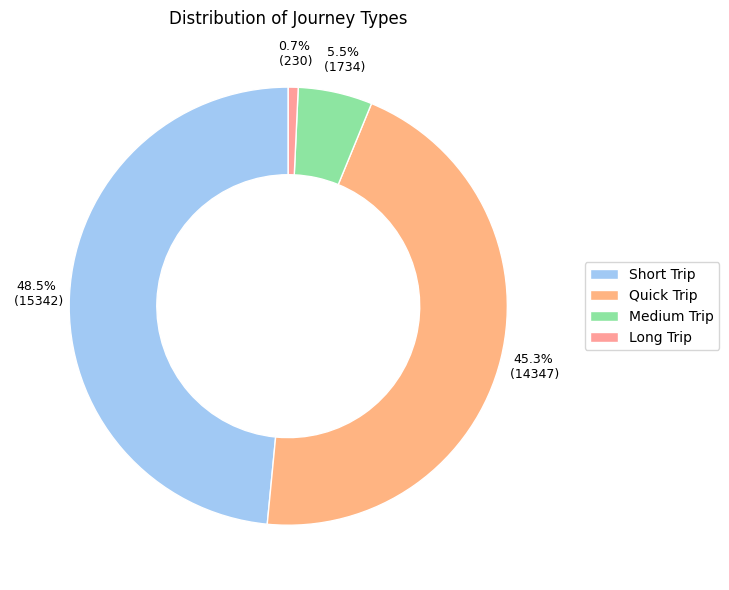

In [62]:
Journey_Type_counts = data['Journey_Type'].value_counts()
journey_type_idx = Journey_Type_counts.index

fig, ax = plt.subplots(figsize=(10, 6))

my_auto_pct = lambda p: f'{p:.1f}%\n ({p*Journey_Type_counts.sum()/100:.0f})'

wedges = ax.pie(
    Journey_Type_counts,
    labels=None,
    autopct=my_auto_pct,
    startangle=90,
    colors=colors,
    wedgeprops={'width':0.4, 'edgecolor':'white'},
    pctdistance=1.15,
    textprops={'fontsize':9}
)
ax.legend(wedges[0], journey_type_idx, loc='center right', bbox_to_anchor=(1.3, 0.5), fontsize=10, labelspacing=0.5)
ax.set_title('Distribution of Journey Types')
plt.tight_layout()


sns.heatmap(
    data=ma_tran_2_chieu,     # (Bắt buộc) Bảng dữ liệu đã qua tổng hợp (pivot_table/crosstab)
    
    # --- NHÓM 1: MÀU SẮC & THANG ĐO ---
    cmap='Tên_bảng_màu',      # Bản đồ màu (vd: 'Blues', 'Oranges', 'coolwarm', 'RdYlGn')
    vmin=None, vmax=None,     # Ép giới hạn dải màu (vd: vmin=0, vmax=100)
    center=None,              # Điểm neo màu ở giữa (thường dùng cho dữ liệu có số âm và dương)
    
    # --- NHÓM 2: HIỂN THỊ SỐ LIỆU ---
    annot=False,              # Bật chữ số hiện lên giữa các ô màu (True/False)
    fmt='.2g',                # Định dạng chữ số (vd: 'd' cho số nguyên, '.2f' cho 2 số thập phân)
    annot_kws=None,           # Tùy chỉnh font chữ, kích cỡ của số (vd: {"size": 10, "weight": "bold"})
    
    # --- NHÓM 3: GIAO DIỆN Ô VUÔNG ---
    linewidths=0,             # Độ dày của đường kẻ chia ô (vd: 0.5)
    linecolor='white',        # Màu của đường kẻ chia ô
    square=False,             # Ép các ô phải vuông vức hoàn hảo 100% (True/False)
    
    # --- NHÓM 4: TRỤC & CHÚ THÍCH ---
    cbar=True,                # Bật/tắt thanh thước đo màu bên phải
    xticklabels='auto',       # Hiện/ẩn hoặc đổi tên nhãn trục X (có thể truyền list tên mới)
    yticklabels='auto',       # Hiện/ẩn hoặc đổi tên nhãn trục Y
    
    # --- NHÓM 5: NÂNG CAO ---
    mask=None                 # Che đi một phần của biểu đồ (cực kỳ hữu ích khi vẽ ma trận tương quan)
)

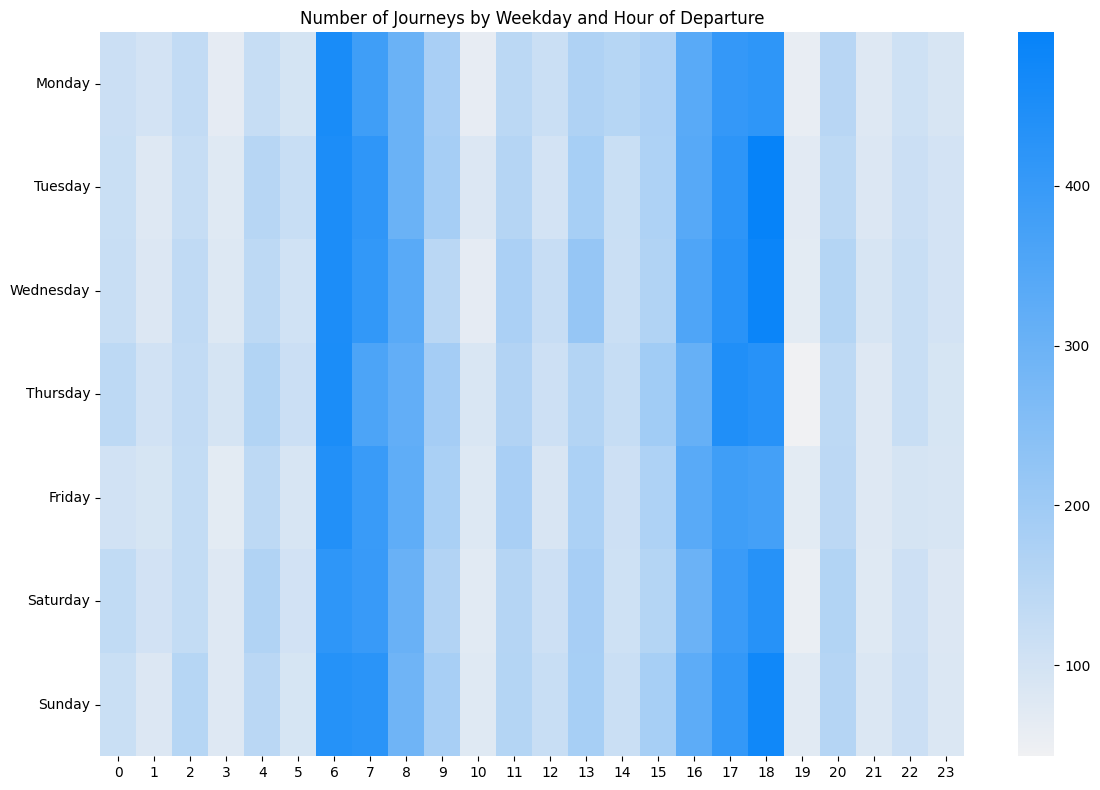

In [70]:
data['Weekday_Journey'] = data['Date_of_Journey'].dt.day_name()
data['Hour_Journey'] = data['Departure_Time'].apply(lambda x: x.hour if pd.notna(x) else np.nan)
data['Weekday_Journey'] = pd.Categorical(data['Weekday_Journey'], categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)

heatmap_data = pd.crosstab(
    columns=data['Hour_Journey'],
    index=data['Weekday_Journey'],
    values=data['Transaction_ID'],
    aggfunc='count' 
)
plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    data=heatmap_data,
    annot=False, #Hiển thị số trong ô
    fmt='g',
    cmap=sns.light_palette("#0683F9", as_cmap=True), # Tạo colormap từ mã màu hex
    cbar_kws={'label': ''}
)
plt.yticks(rotation=0)
ax.set_title('Number of Journeys by Weekday and Hour of Departure')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()

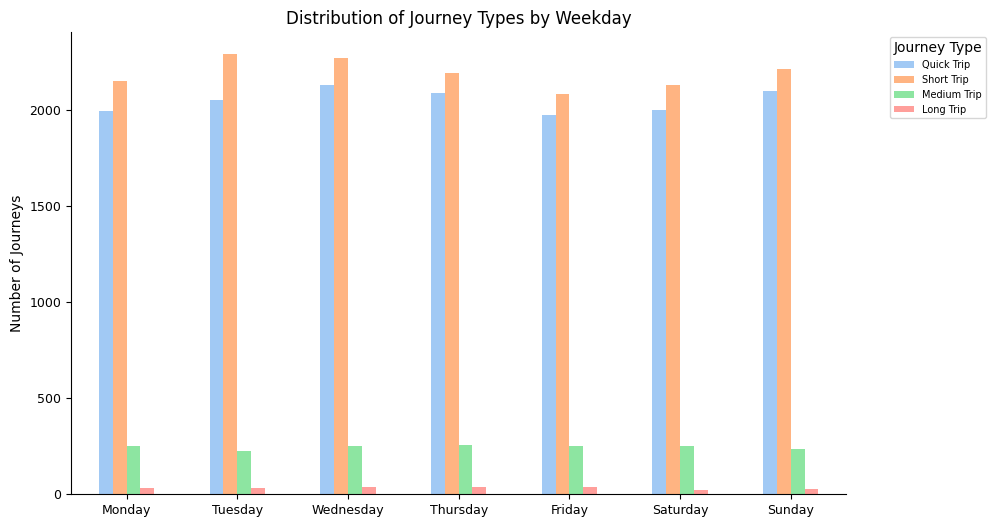

In [64]:
pattern_trip_day = pd.crosstab(
    columns=data['Journey_Type'],
    index=data['Weekday_Journey'],
    values=data['Transaction_ID'],
    aggfunc='count'
)


ax = pattern_trip_day.plot(
    kind='bar',
    stacked=False,
    color=colors,
    rot=0,
    figsize=(10, 6)     
)
ax.set_title('Distribution of Journey Types by Weekday')
ax.set_xlabel('')
ax.set_ylabel('Number of Journeys')
ax.tick_params(axis='both', labelsize=9)

ax.legend(title='Journey Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, labelspacing=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

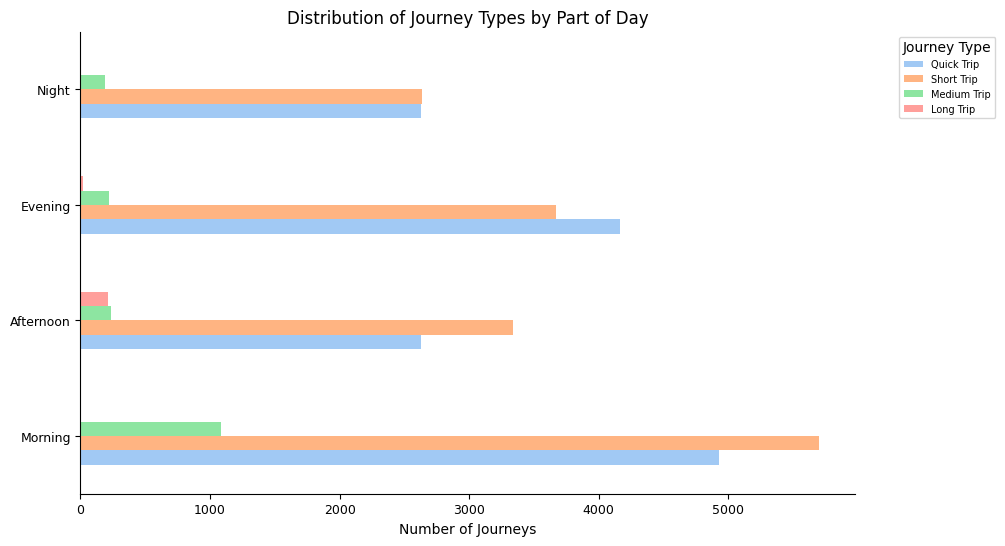

In [65]:
pattern_trip_part_of_day = pd.crosstab(
    columns=data['Journey_Type'],
    index=journey_time['Part_of_Day'],
    values=data['Transaction_ID'],
    aggfunc='count'
)

ax = pattern_trip_part_of_day.plot(
    kind='barh',
    stacked=False,
    color=colors,
    rot=0,
    figsize=(10, 6)
)
ax.set_title('Distribution of Journey Types by Part of Day')
ax.set_xlabel('Number of Journeys')
ax.set_ylabel('')
ax.tick_params(axis='both', labelsize=9)
ax.legend(title='Journey Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, labelspacing=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [66]:
trip_share_by_price = pd.crosstab(
    index=data['ticket_price_class'],
    columns=data['Journey_Type'],
    values=data['Transaction_ID'],
    aggfunc='count'
).fillna(0)

trip_share_by_price

Journey_Type,Quick Trip,Short Trip,Medium Trip,Long Trip
ticket_price_class,,,,
First Class-High,1.0,212.0,130.0,9.0
First Class-Low,783.0,23.0,0.0,0.0
First Class-Medium,380.0,302.0,11.0,0.0
First Class-Medium High,149.0,1016.0,23.0,19.0
Standard-High,0.0,303.0,573.0,0.0
Standard-Low,11143.0,7501.0,0.0,0.0
Standard-Medium,1877.0,3713.0,143.0,125.0
Standard-Medium High,14.0,2272.0,854.0,77.0


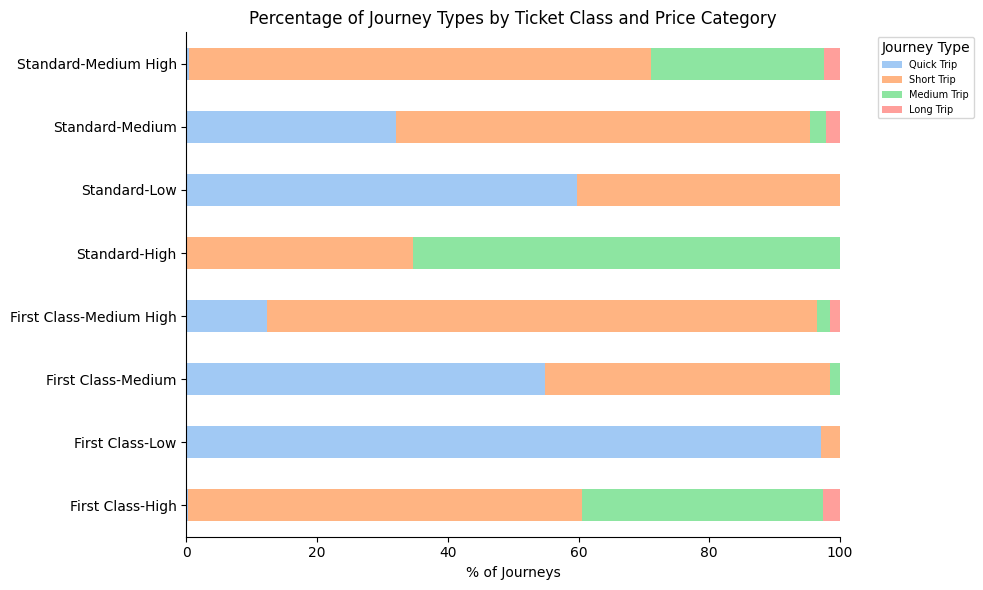

In [67]:
trip_share_by_price_pct = trip_share_by_price.div(trip_share_by_price.sum(axis=1), axis=0).round(4)*100
ax = trip_share_by_price_pct.plot(
    kind='barh',
    stacked=True,
    color=colors,
    figsize=(10, 6),
    rot=0
)
ax.set_title('Percentage of Journey Types by Ticket Class and Price Category')
ax.set_xlabel('% of Journeys')
ax.set_ylabel('')
ax.legend(title='Journey Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, labelspacing=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

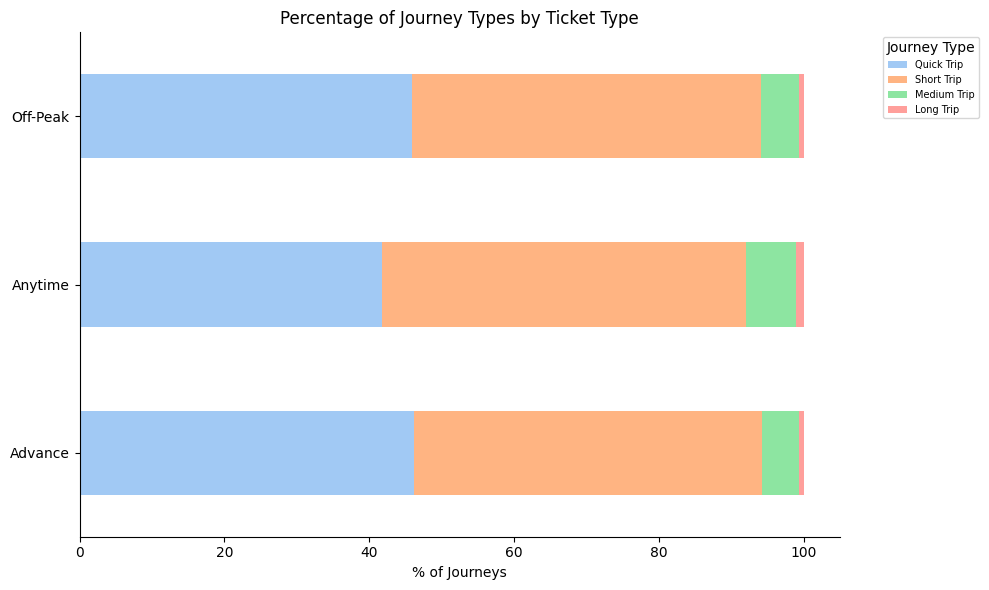

In [68]:
trip_share_by_ticket_type = pd.crosstab(
    index=data['ticket_type'],
    columns=data['Journey_Type'],
    values=data['Transaction_ID'],
    aggfunc='count'
).fillna(0)
trip_share_by_ticket_type_pct = trip_share_by_ticket_type.div(trip_share_by_ticket_type.sum(axis=1), axis=0).round(4)*100
ax = trip_share_by_ticket_type_pct.plot(
    kind='barh',
    stacked=True,
    color=colors,
    figsize=(10, 6),
    rot=0
)
ax.set_title('Percentage of Journey Types by Ticket Type')
ax.set_xlabel('% of Journeys')
ax.set_ylabel('')
ax.legend(title='Journey Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, labelspacing=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

<Figure size 1000x600 with 0 Axes>

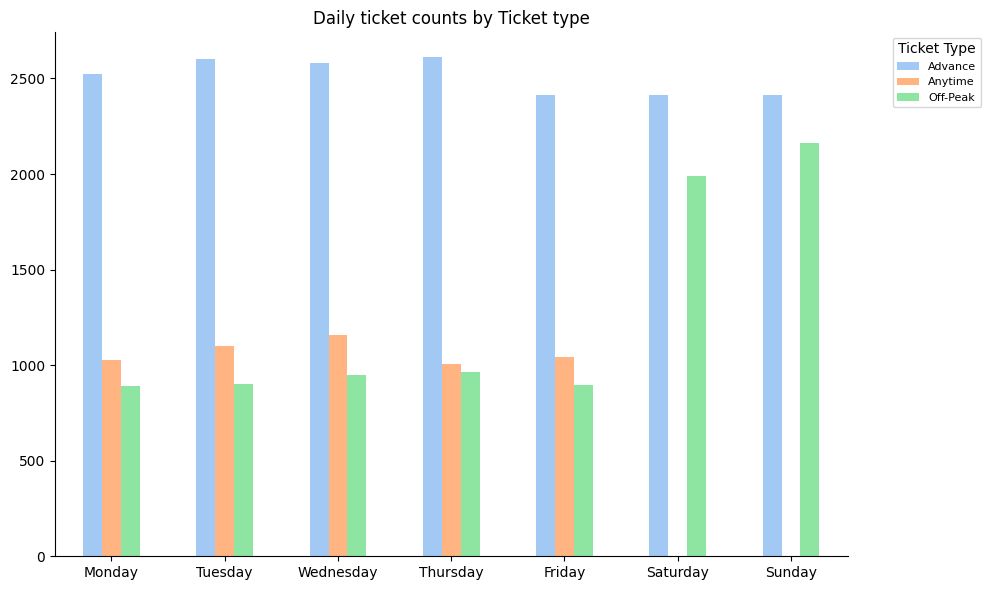

In [69]:
trip_share_by_day = pd.crosstab(
    index=data['Weekday_Journey'],
    columns=data['ticket_type'],
    values=data['Transaction_ID'],
    aggfunc='count'
).fillna(0)
plt.figure(figsize=(10, 6))
ax = trip_share_by_day.plot(
    kind='bar',
    stacked=False,
    color=colors,
    figsize=(10, 6), 
    rot=0
)
ax.set_title('Daily ticket counts by Ticket type')
ax.set_xlabel('')  
ax.legend(title='Ticket Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, labelspacing=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()